In [1]:
# Import the nltk library
import nltk

# Download Libraries
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

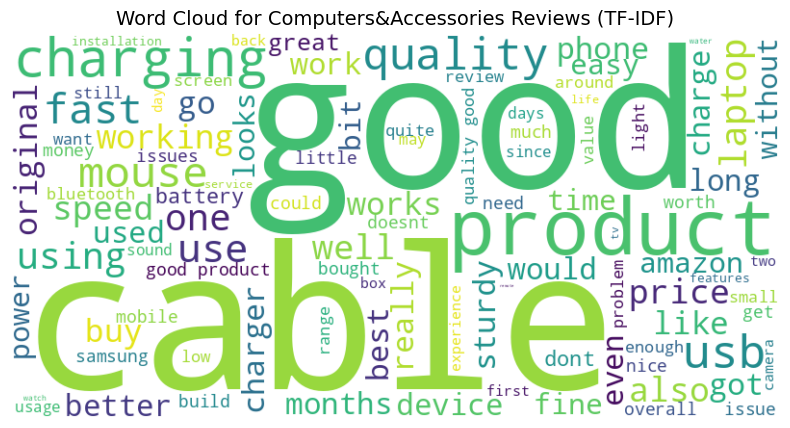

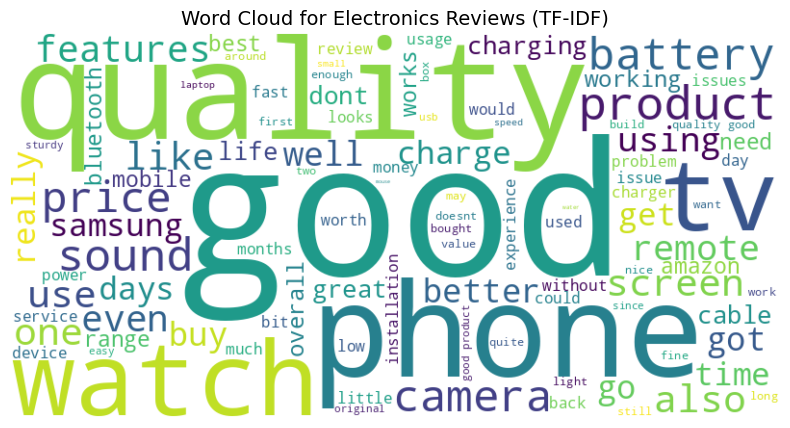

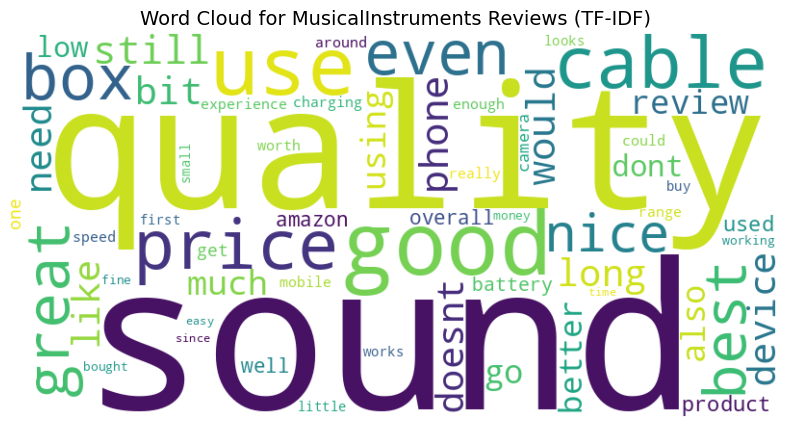

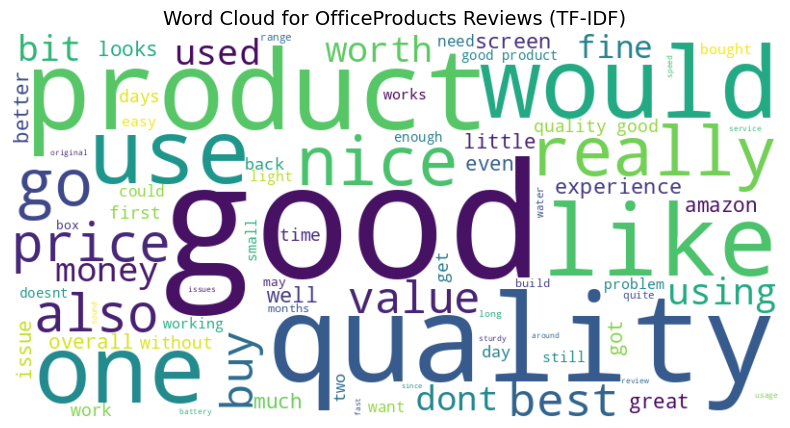

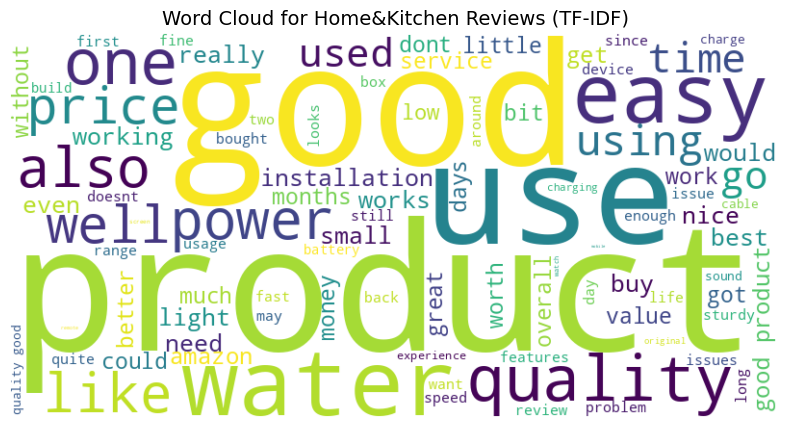

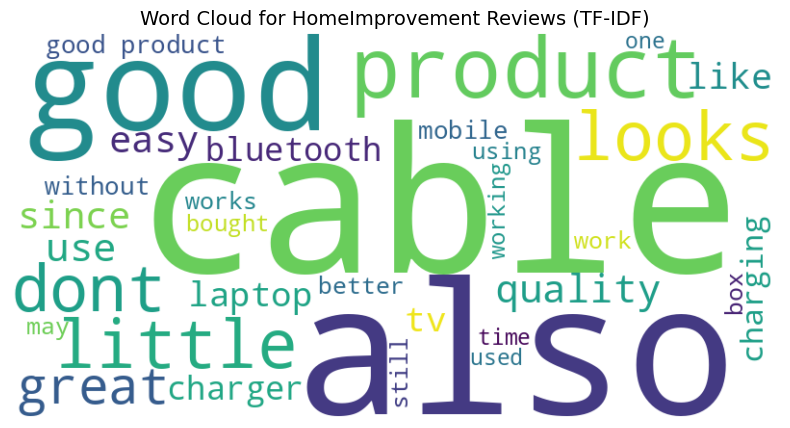

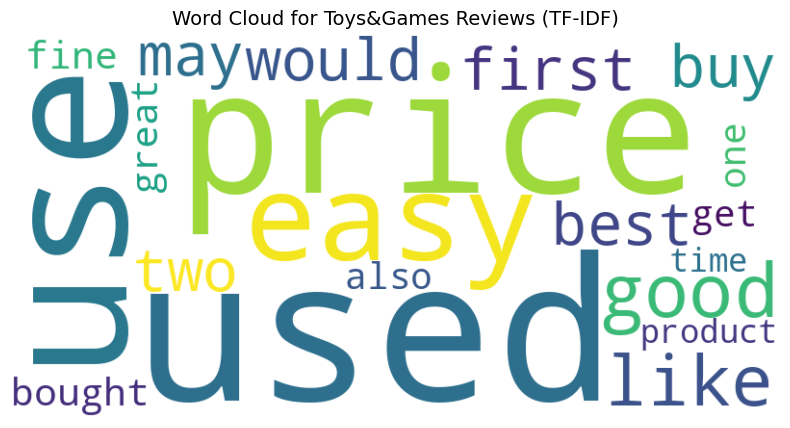

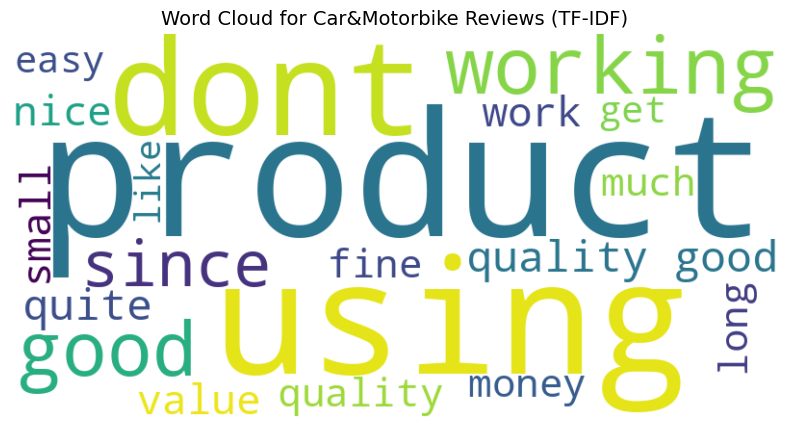

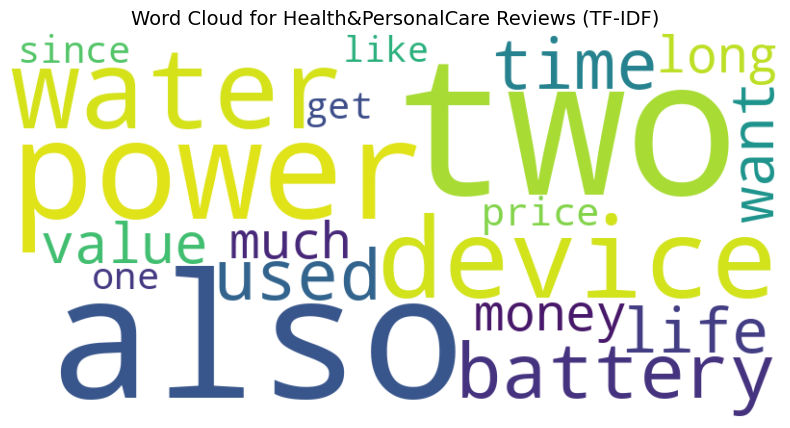

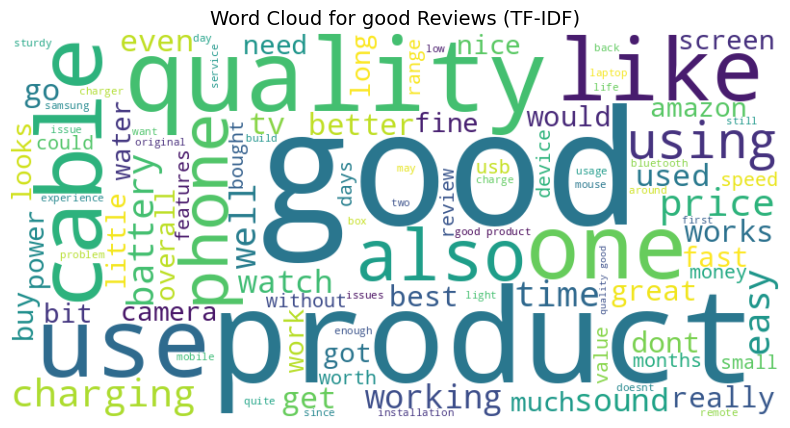

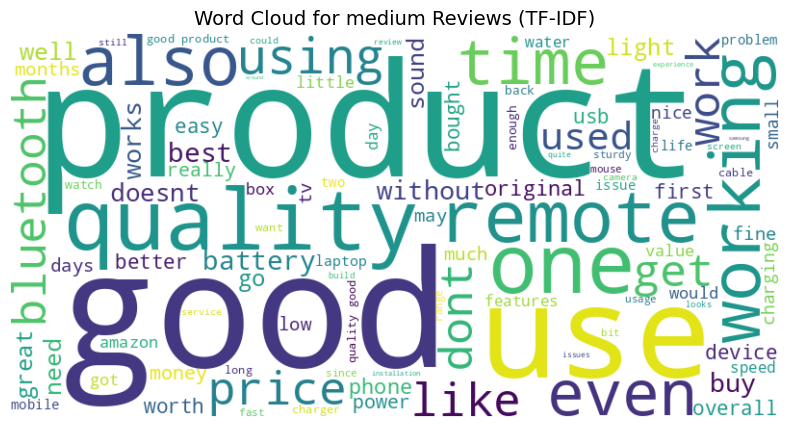

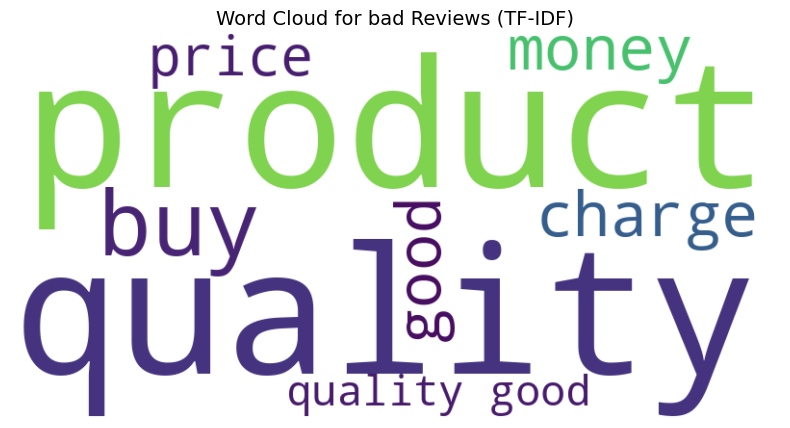

In [3]:
import pandas as pd
import string
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords


# Load your dataset
amazon = pd.read_csv('/content/drive/MyDrive/AmazonProject/amazon.csv')

# Ensure 'review_content' and 'category' exist and create category_super_set
amazon = amazon.dropna(subset=['review_content', 'category'])

amazon['rating'] = pd.to_numeric(amazon['rating'], errors='coerce')
amazon['review_content'] = amazon['review_content'].astype(str)  # Ensure reviews are strings
amazon.dropna(subset=['rating', 'review_content'], inplace=True)

# Create category_super_set column by extracting the first part of the category
amazon['category_super_set'] = amazon['category'].apply(lambda x: x.split('|')[0])

# Categorize reviews based on rating
def categorize_review(rating):
    if rating < 2.5:
        return 'bad'
    elif 2.5 <= rating <= 3.5:
        return 'medium'
    else:
        return 'good'

amazon['review_category'] = amazon['rating'].apply(categorize_review)

# Preprocess text function: Remove punctuation, convert to lowercase, and remove stopwords
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    return [word for word in words if word not in stop_words]

# Combine all reviews per category_super_set or review_category
def combine_reviews_by_category(df, category_column):
    combined_reviews = {}
    for category in df[category_column].unique():
        reviews = df[df[category_column] == category]['review_content'].dropna().apply(preprocess_text)
        combined_reviews[category] = ' '.join([' '.join(review) for review in reviews])
    return combined_reviews

# TF-IDF Vectorization
def compute_tfidf(combined_reviews):
    tfidf_vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(combined_reviews.values())
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Collect TF-IDF scores for each category
    tfidf_scores = {}
    for idx, category in enumerate(combined_reviews.keys()):
        scores = tfidf_matrix[idx].toarray()[0]
        tfidf_scores[category] = dict(zip(feature_names, scores))
    return tfidf_scores

# Function to generate word cloud
def generate_wordcloud(tfidf_scores, category, color='viridis'):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=color, max_words=300).generate_from_frequencies(tfidf_scores[category])
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {category} Reviews (TF-IDF)", fontsize=14)
    plt.show()

# Combine reviews by 'category_super_set'
combined_reviews_by_super_set = combine_reviews_by_category(amazon, 'category_super_set')

# Compute TF-IDF scores for each category_super_set
tfidf_scores_by_super_set = compute_tfidf(combined_reviews_by_super_set)

# Generate word clouds for each category_super_set
for category in combined_reviews_by_super_set.keys():
    generate_wordcloud(tfidf_scores_by_super_set, category)

# Combine reviews by 'review_category'
combined_reviews_by_review_category = combine_reviews_by_category(amazon, 'review_category')

# Compute TF-IDF scores for each review_category
tfidf_scores_by_review_category = compute_tfidf(combined_reviews_by_review_category)

# Generate word clouds for each review_category
for category in combined_reviews_by_review_category.keys():
    generate_wordcloud(tfidf_scores_by_review_category, category)
